In [10]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
#color_list = sns.color_palette() + sns.color_palette("Set2") + sns.color_palette("Set3")
color_list = (
    sns.color_palette("colorblind", 10) +
    sns.color_palette("Dark2", 8) +
    sns.color_palette("tab20", 20)
)

dim = 3
save_dir = f'data/{dim}d/rpa'

# single run with and without refinent (maybe also compare with tprc method)
# rest with more runs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


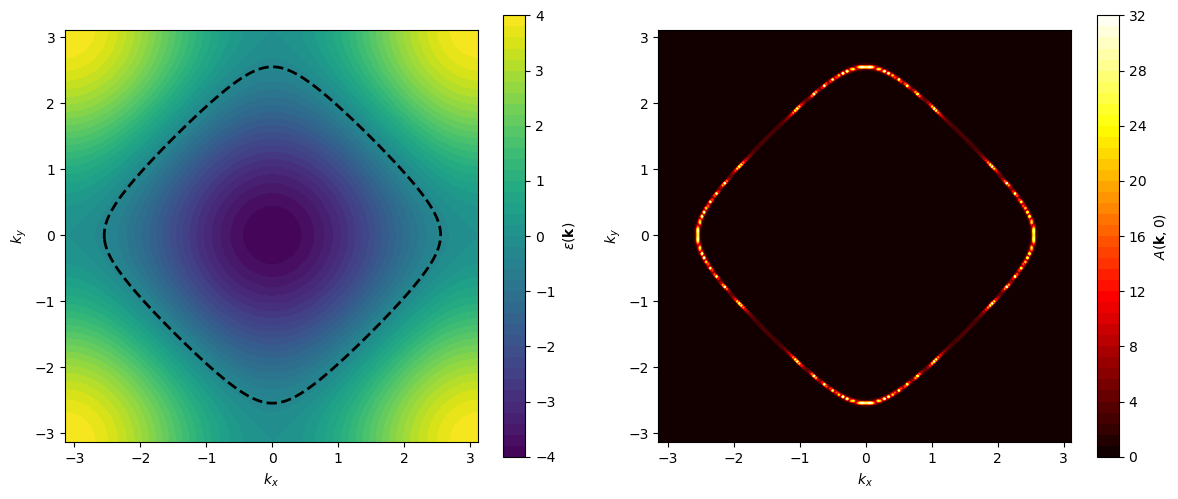

In [6]:
import numpy as np
import matplotlib.pyplot as plt

square = LATTICE(dim=2, tp=0.)
nk = 200

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

# --- Compute A(k,0) ---
eta = 0.01  # broadening, tune to ~pi*T or Im Sigma(0)
mu = get_mu(e_k=square.e_k, n_goal=0.9, beta=1/1)
Ak0 = (1/np.pi) * eta / (eta**2 + (eps - mu)**2)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: dispersion + bare FS ---
ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

# --- Plot 2: A(k,0) ---
ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
#ax.contour(kx, ky, eps, levels=[mu], colors='cyan', linewidths=1, linestyles='--')
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

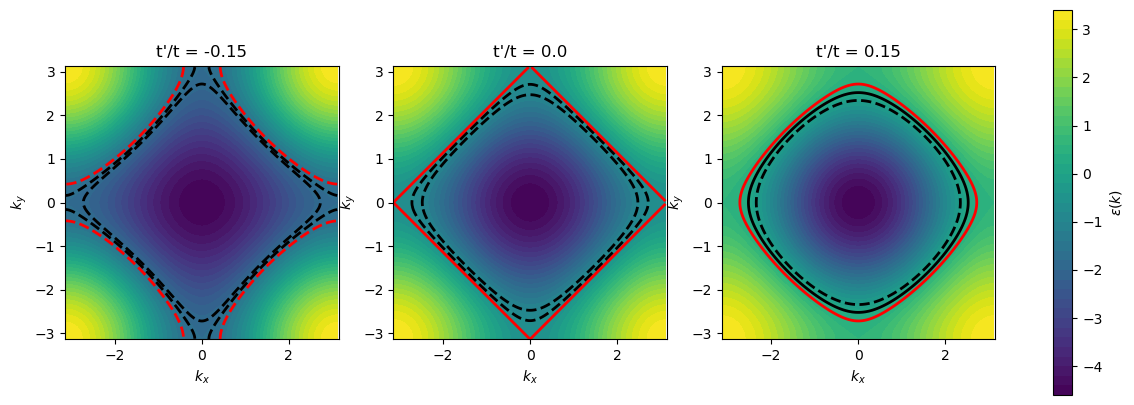

In [8]:
import numpy as np
import matplotlib.pyplot as plt

tp_list = [-0.15, 0., 0.15]

nk = 200

k_mesh, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.01
n_list = [0.8, 0.9, 1.]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tp in zip(axes, tp_list):
    square = LATTICE(dim=2, tp=tp)
    
    square.get_e_k(nk)
    eps = square.e_k.data[:, 0, 0].real
    eps = eps.reshape(nk, nk)
    eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

    cf = ax.contourf(kx, ky, eps, levels=50)

    mu_list = [get_mu(e_k=square.e_k, n_goal=n, beta=1/T) for n in n_list]
    ax.contour(kx, ky, eps, levels=mu_list[:-1], colors='black', linewidths=2)
    ax.contour(kx, ky, eps, levels=[mu_list[-1]], colors='red', linewidths=2)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_title(f"t'/t = {tp}")
    ax.set_aspect('equal')

fig.colorbar(cf, ax=axes, label=r'$\varepsilon(k)$')
plt.show()

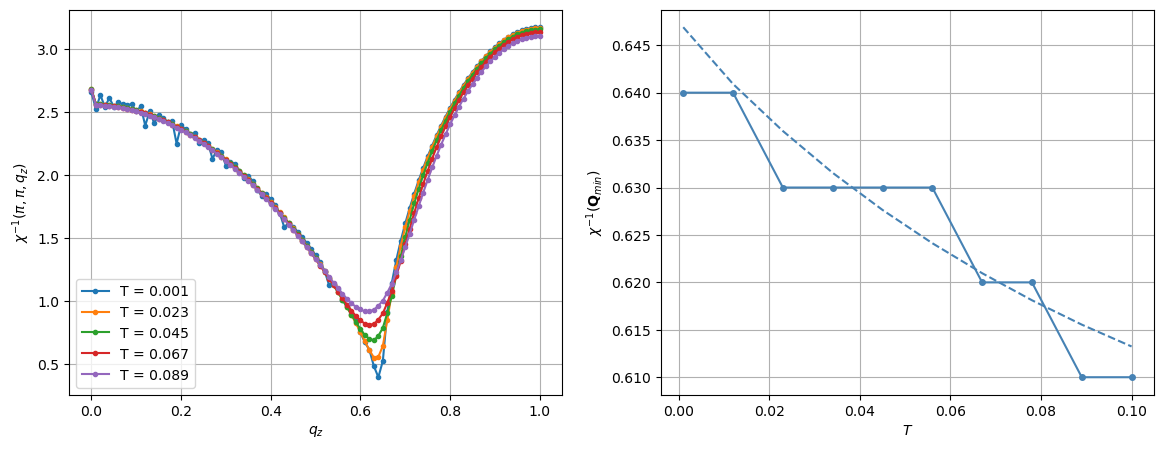

In [ ]:
n = 0.7
T_list = np.linspace(0.001, 0.1, 10)
U = 3

nk = 200
cube = LATTICE()
cube.get_e_k(nk=nk)
cube.get_phase_k(nk)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel(r'$\chi^{-1}(\mathbf{Q}_{min})$')

qz_path = np.linspace(0., 1., nk//2+1)
Qz = []
Qz_refined = []
for i, T in enumerate(T_list):
    mu = get_mu(cube.e_k, n, 1/T)

    invchi = []
    for qz in qz_path:
        q = np.array([1.,1.,qz])

        e_k, e_kq = cube.get_e_kq(q, 'coarse')
        S_k = e_k*0
        invchi.append(1/lindhard_ksp(mu, 1/T, e_k, e_kq, S_k, S_k) - U)

    if i%2 == 0:
        ax[0].plot(qz_path, invchi, 'o-', markersize=3, label=f'T = {T:.3f}')

    idx = np.argmin(invchi)
    Qz.append(qz_path[np.argmin(invchi)])
    #ax[0].axvline(Qz[-1], linestyle='--', color=color)

    start = qz_path[0]
    end   = qz_path[-1]
    step  = 1 / (len(qz_path) - 1)

    def invchi0(s):

        qz_pt = start + s * (end - start)
        q_pt = np.array([1.,1.,qz_pt])
        e_k_arr, e_kq_arr = cube.get_e_kq(q_pt, 'fine')

        return 1/lindhard_ksp(mu, 1/T, e_k_arr, e_kq_arr, S_k, S_k) - U

    s0 = idx / (len(qz_path) - 1)
    res = minimize_scalar(invchi0, method='bounded', bounds=(max(0, s0 - 5*step), min(1, s0 + 5*step)))

    s_min = res.x
    Qz_refined.append(start + s_min * (end - start))
    
ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue')
ax[1].plot(T_list, Qz_refined, '--', markersize=4, color='steelblue')
ax[0].legend()

for a in ax:
    a.grid()
plt.show()

[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   2 out of  11 | elapsed:    3.0s remaining:   13.5s
[Parallel(n_jobs=11)]: Done   4 out of  11 | elapsed:    3.2s remaining:    5.7s
[Parallel(n_jobs=11)]: Done   6 out of  11 | elapsed:    3.7s remaining:    3.1s
[Parallel(n_jobs=11)]: Done   8 out of  11 | elapsed:    4.6s remaining:    1.7s
[Parallel(n_jobs=11)]: Done  11 out of  11 | elapsed:    4.9s finished


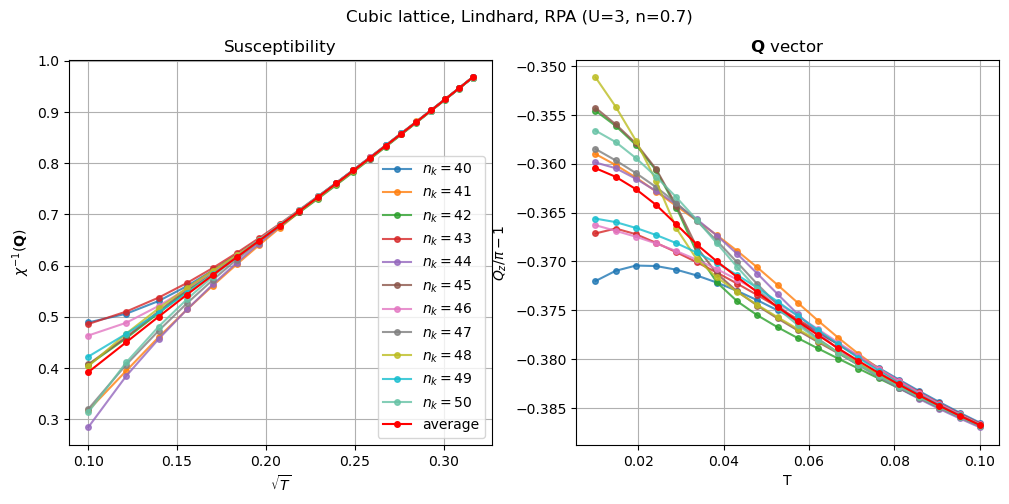

In [ ]:
U = 3
n = 0.7
T_list = np.linspace(0.001, 0.01, 20)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard, RPA (U={U}, n={n})'

nk_list = list(range(140, 151, 1))
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1])} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=11)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5,
                        title=title, label=f'$n_k={nk}$', figure=fig, alpha=0.8)
    
fig, _ = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), fit=False, x_exp=0.5,
                    title=title, label=f'average', figure=fig, color='red')

plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Starting serial run at: 2026-05-10 17:07:36.513772
Starting serial run at: 2026-05-10 17:07:36.513941
Starting serial run at: 2026-05-10 17:07:36.520056
Starting serial run at: 2026-05-10 17:07:36.571053
Starting serial run at: 2026-05-10 17:07:36.573867
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  8.4min remaining: 12.6min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  8.5min remaining:  5.7min


n = 0.6 : ampl = 3.1740408075090834, exp = 0.5885428477379999, Tc = -0.06847717766325742
n = 0.65 : ampl = 2.7539761658982482, exp = 0.5505048006902485, Tc = -0.034281648129202105
n = 0.7 : ampl = 3.2483204411915962, exp = 0.6589795603591738, Tc = -0.023044947321150616
n = 0.75 : ampl = 2.502413654546775, exp = 0.5520907358881966, Tc = 0.00010859458854027088
n = 0.8 : ampl = 2.338332059310279, exp = 0.5380124652241255, Tc = 0.01837129925213769


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  8.7min finished


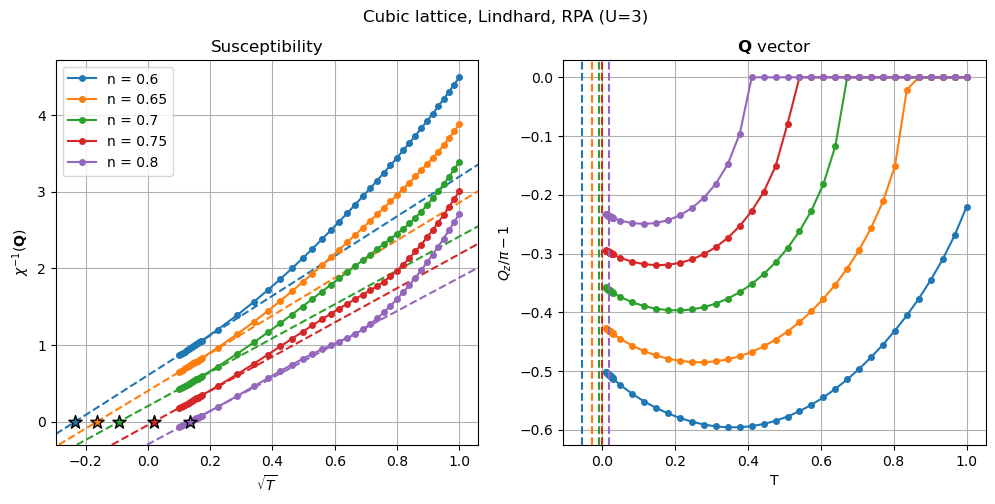

In [ ]:
U = 3
n_list = np.linspace(0.6, 0.8, 5)
T_list = np.concatenate([np.linspace(0.01, 0.05, 15), np.linspace(0.05, 1., 30)])
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 150
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    ampl = results['ampl']
    gamma = results['gamma']
    print(f"n = {n} : ampl = {ampl}, exp = {gamma}, Tc = {Tc}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5, fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[1]/fit[0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.6, 0.8, 5)
T_list = np.linspace(0.01, 0.1, 30)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 150
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig, ax = plt.subplots(figsize=(12, 5))
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    c = results['c']

    invchi = np.array(results['invchi'])
    T = np.log(np.array(T_list))

    y = np.log(invchi - c)
    dy_dT = np.gradient(y, T)

    ax.plot(T_list, dy_dT, 'o-', label=f"n={n}")
    color = ax.lines[-1].get_color()
    ax.axvline(Tc, linestyle='--', color=color)

ax.grid()
ax.set_xlabel("T")
ax.set_ylabel(r"$d/dT \, \ln(\mathrm{inv}\chi - c)$")
ax.set_xscale('log')
ax.set_xlim(left=0.004)
ax.legend()

plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
Starting serial run at: 2026-05-11 16:54:03.036040
Starting serial run at: 2026-05-11 16:54:03.040445
Starting serial run at: 2026-05-11 16:54:03.041236


Starting serial run at: 2026-05-11 16:54:03.056086
Starting serial run at: 2026-05-11 16:54:03.094143


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   13.1s finished


fit1: n = 0.88 : exp = 0.04817021152985477, ampl = 6.325598375450103
fit2: n = 0.88 : exp = 0.8024759193677553, ampl = 0.9525524691943074
fit1: n = 0.89 : exp = 2.6840319483046398, ampl = 6.575997586244648
fit2: n = 0.89 : exp = 1.3794061184190802, ampl = 3.9224447031630905
fit1: n = 0.9 : exp = 1.6642749397962295, ampl = 3.3350502239803257
fit2: n = 0.9 : exp = 1.1180186691259415, ampl = 3.244677345991099


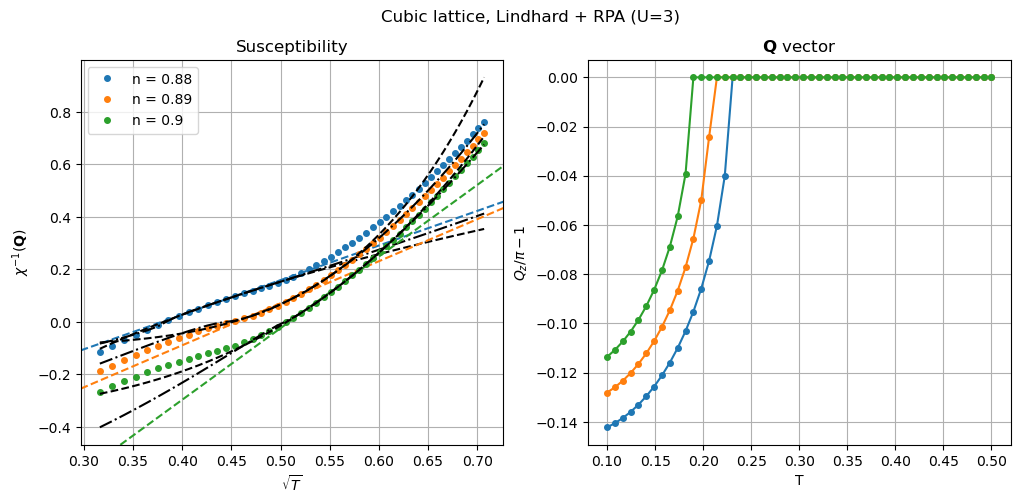

In [14]:
U = 3
n_list = np.linspace(0.88, 0.9, 3)
T_list = np.linspace(0.1, 0.5, 50)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard + RPA (U={U})'

nk = 50
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'fit_type': [critical1, critical2]} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=3)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    ampl = results['ampl']
    gamma = results['gamma']
    c = results['c']
    print(f'fit1: n = {n} : exp = {gamma[0]}, ampl = {ampl[0]}')
    print(f'fit2: n = {n} : exp = {gamma[1]}, ampl = {ampl[1]}')
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5,
                        title=title, label=f'n = {n}', figure=fig, styles=('o','o-'))

    _, axs = fig
    axs[0].plot(T_list**0.5, critical1(T_list, ampl[0], gamma[0], c[0]), '--', color='black')
    axs[0].plot(T_list**0.5, critical2(T_list, ampl[1], gamma[1], c[1]), '-.', color='black')

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-08 08:47:09.601029
Starting serial run at: 2026-05-08 08:47:09.602177
Starting serial run at: 2026-05-08 08:47:09.609273
Starting serial run at: 2026-05-08 08:47:09.638499
Starting serial run at: 2026-05-08 08:47:09.638526
Starting serial run at: 2026-05-08 08:47:09.649912
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:    2.5s remaining:    5.0s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    2.5s remaining:    2.5s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:    2.6s remaining:    1.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    2.6s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   33.5s remaining:  1.1min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   34.1s remaining:   34.1s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:   34.2s remaining:   17.1s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   34.5s finished

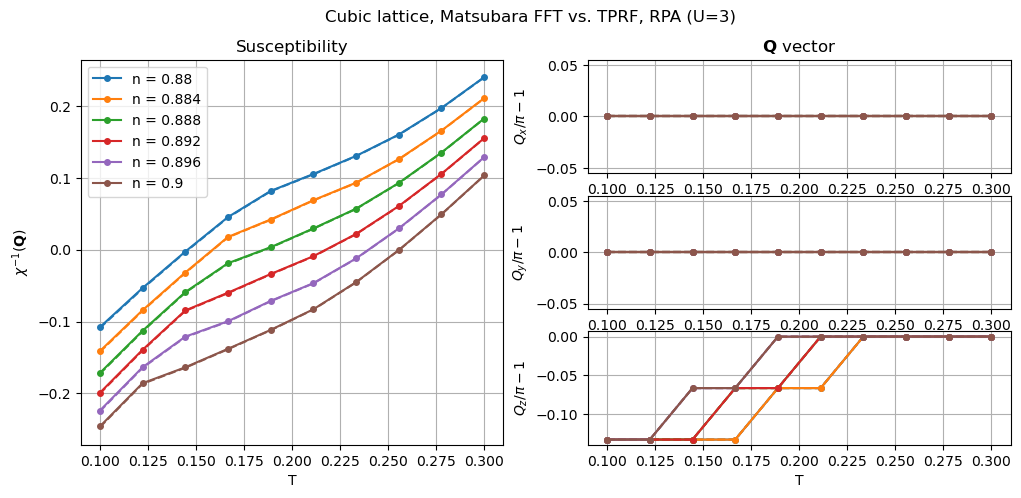

In [ ]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 10)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. TPRF, RPA (U={U})'

nk = 30
niw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_fft', 'niw': niw, 'niw_extr': True} for par_dict in par_list]
results_list_fft = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_tprf', 'niw': niw} for par_dict in par_list]
results_list_tprf = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_fft, res_tprf in zip(results_list_fft, results_list_tprf):
    n = res_fft['par_list'][0]['n']
    fig, fit = pcut_chi(res_fft, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_tprf, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   24.5s remaining:   49.1s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   24.6s remaining:   24.6s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:   24.6s remaining:   12.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   24.8s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:    3.3s remaining:    6.6s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    3.5s remaining:    3.5s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:    3.6s remaining:    1.8s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    3.9s finished


n = 0.88 : exp_mats = 0.00459947385692727, exp_lindh = 0.6090094017234252
n = 0.884 : exp_mats = 1.5042907976424826, exp_lindh = 1.4066120748489646
n = 0.888 : exp_mats = 3.0881358593315054, exp_lindh = 3.1278245090513668
n = 0.892 : exp_mats = 2.557290557810163, exp_lindh = 2.5585820870013025
n = 0.896 : exp_mats = 2.1905518747293957, exp_lindh = 2.191427703925661
n = 0.9 : exp_mats = 1.9623109816835178, exp_lindh = 1.962990711041491


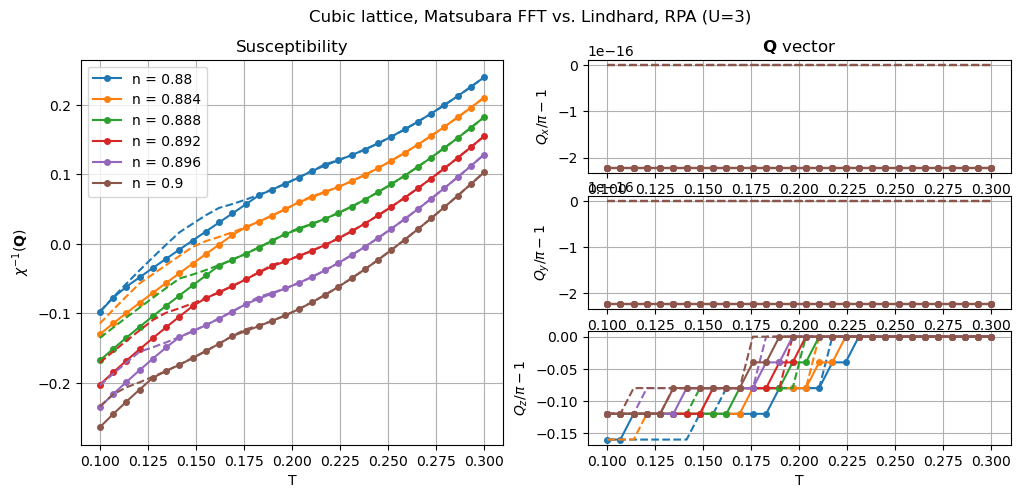

In [ ]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 30)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U})'

nk = 50
niw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'niw': niw, 'niw_extr': True} for par_dict in par_list]
results_list_mats = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
results_list_lindh = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_mats, res_lindh in zip(results_list_mats, results_list_lindh):
    n = res_mats['par_list'][0]['n']
    print(f"n = {n} : exp_mats = {res_mats['gamma']}, exp_lindh = {res_lindh['gamma']}")
    fig, fit = pcut_chi(res_mats, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_lindh, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Starting serial run at: 2026-05-07 20:46:14.200291
Starting serial run at: 2026-05-07 20:46:14.244642
Starting serial run at: 2026-05-07 20:46:14.251451
Starting serial run at: 2026-05-07 20:46:14.256328
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:  1.8min
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:  2.1min remaining:  2.1min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  4.5min finished


Completed 15 jobs in 471.72 seconds | U=3.000, T=0.050, n=0.700
Completed 15 jobs in 290.38 seconds | U=3.000, T=0.050, n=0.700


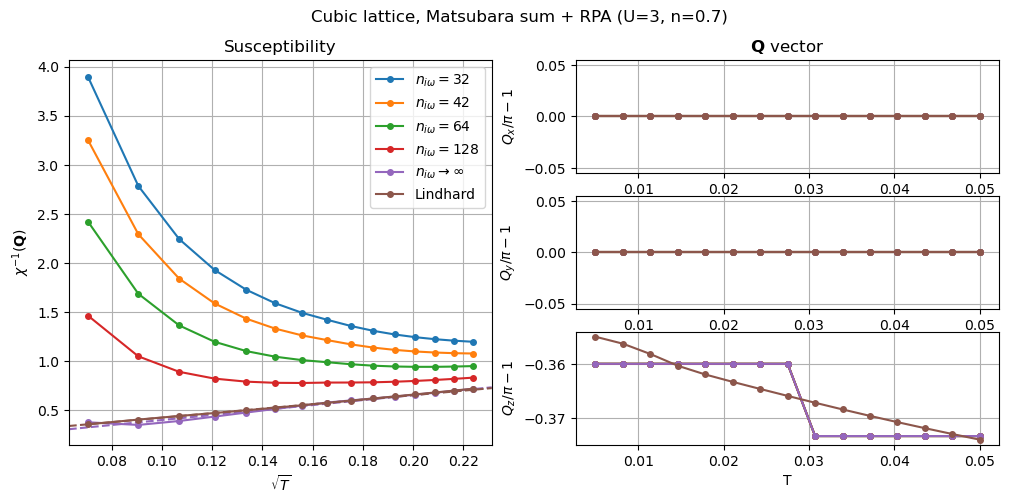

In [ ]:
U = 3
n = 0.7
T_list = np.linspace(0.005, 0.05, 15)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U}, n={n})'

nk = 150
niw_list = 128//np.array([4,3,2,1])

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'niw': niw, 'niw_extr': False, 'method': 'matsubara_fft'} for niw in niw_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=4)

fig = None
for results in results_list:
    niw = results['niw']
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=False, x_exp=0.5, title=title, label=f'$n_{{i\omega}}={niw}$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, method='matsubara_fft', niw=niw_list[-1], niw_extr=True)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label=r'$n_{{i\omega}}\to\infty$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label='Lindhard', figure=fig)

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.04, 15)

nk = 150
file = f'{save_dir}/nTdiag_U3tp0.00'
if os.path.exists(file):
    results = HDFread_list(file, ['Xc'])
    n_old = [par_list[0]['n'] for par_list in results['par_list']]
    Tc_old = [x[0] for x in results['Xc']]
    Tc = np.interp(n_list, n_old, Tc_old)
else:
    print(f'file {file} does not exist!')

par_list = []
for i, n in enumerate(n_list):
    par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1]),
               'fit': True, 'fit_type': [critical1, critical2, critical3], 'fix_exp': [None, None, 0.5]} for par_dict in par_list]
results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=12, save_file=file)

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
Starting serial run at: 2026-05-15 00:04:29.516573


Starting serial run at: 2026-05-15 00:04:29.520912
Starting serial run at: 2026-05-15 00:04:29.520922
Starting serial run at: 2026-05-15 00:04:29.548724
Starting serial run at: 2026-05-15 00:04:29.548748
Starting serial run at: 2026-05-15 00:04:29.579383
Starting serial run at: 2026-05-15 00:04:29.625591
Starting serial run at: 2026-05-15 00:04:29.625591
Starting serial run at: 2026-05-15 00:04:29.625605
Starting serial run at: 2026-05-15 00:04:29.625614
Starting serial run at: 2026-05-15 00:04:29.636705
Starting serial run at: 2026-05-15 00:04:29.636721
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:  2.1min
[Parallel(n_jobs=12)]: Done   4 out of  24 | elapsed:  2.3min remaining: 11.6min
[Parallel(n_jobs=12)]: Done   7 out of  24 | elapsed:  2.4min remaining:  5.9min
[Parallel(n_jobs=12)]: Done  10 out of  24 | elapsed:  2.5min remaining:  3.4min
[Parallel(n_jobs=12)]: Done  13 out of  24 | elapsed:  4.3min remaining:  3.6min
[Parallel(n_jobs=12)]: Done  16 out of  24 | elapsed:

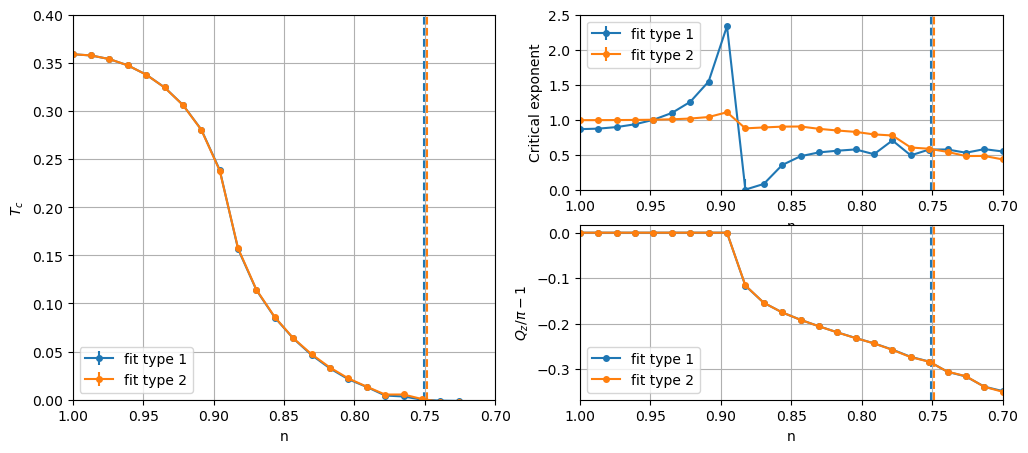

In [38]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.7, 1)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_z/\pi-1$')

results = HDFread_list(f'{save_dir}/nTdiag_U3tp0.00', ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
n_fits = len(results['Xc'][0]) - 1

for i in range(n_fits)[:2]:
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[i][-1]-1 for Q in results['Qc']]
    Xc = [x[i] for x in results['Xc']]
    Xc_err = [x[i] for x in results['Xc_err']]
    gamma = [x[i] for x in results['gamma']]
    gamma_err = [x[i] for x in results['gamma_err']]

    ax[0].errorbar(n_list, Xc, Xc_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    ax[1].errorbar(n_list, gamma, gamma_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"fit type {i+1}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., Xc, n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.savefig(f'{save_dir}/fit_type.png', dpi=100)
plt.show()

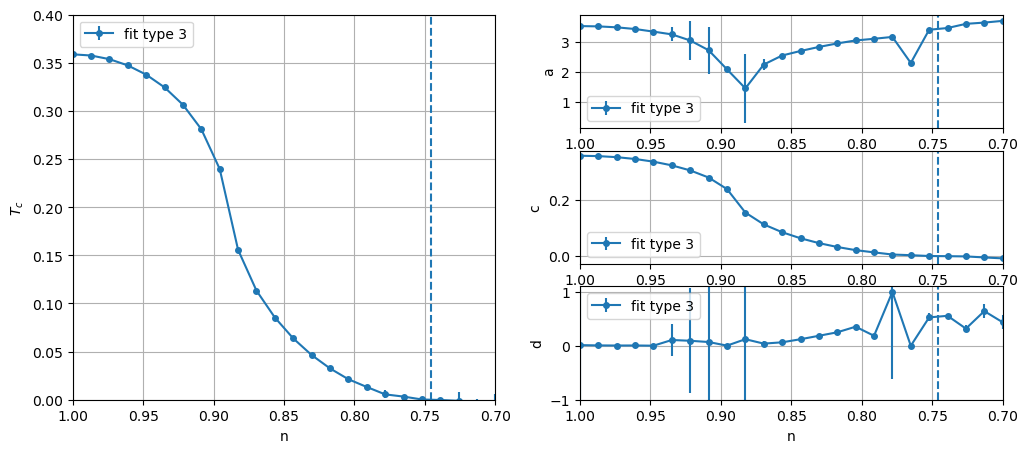

In [39]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.7, 1)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.4)
#ax[1].set_ylim(0., 2.5)
ax[3].set_ylim(-1,1.1)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('a')
ax[2].set_ylabel('c')
ax[3].set_ylabel('d')

results = HDFread_list(f'{save_dir}/nTdiag_U3tp0.00', ['Xc', 'Xc_err', 'ampl', 'ampl_err', 'c', 'c_err', 'd', 'd_err'])

n_list = [par_list[0]['n'] for par_list in results['par_list']]
Xc = [x[2] for x in results['Xc']]
Xc_err = [x[2] for x in results['Xc_err']]
ampl = [x[2] for x in results['ampl']]
ampl_err = [x[2] for x in results['ampl_err']]
c = [x[2] for x in results['c']]
c_err = [x[2] for x in results['c_err']]
d = [x[-1] for x in results['d']]
d_err = [x[-1] for x in results['d_err']]

ax[0].errorbar(n_list, Xc, Xc_err, fmt='o-', label=f"fit type {2+1}", markersize=4)
ax[1].errorbar(n_list, ampl, ampl_err, fmt='o-', label=f"fit type {2+1}", markersize=4)
ax[2].errorbar(n_list, c, c_err, fmt='o-', label=f"fit type {2+1}", markersize=4)
ax[3].errorbar(n_list, d, d_err, fmt='o-', label=f"fit type {2+1}", markersize=4)
color = ax[0].lines[-1].get_color()

n_crit = np.interp(0., Xc, n_list)
for a in ax:
    a.axvline(n_crit, linestyle='--', color=color)
    a.legend()

plt.savefig(f'{save_dir}/fit_type.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 200
niw = 128
tp_list = [0., 0.05, 0.1, 0.15, 0.2]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': False} for #par_dict in par_list]
    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
                   'method': 'lindhard', 'refine': False, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 10:09:39.097858
Starting serial run at: 2026-05-15 10:09:39.097942
Starting serial run at: 2026-05-15 10:09:39.098746
Starting serial run at: 2026-05-15 10:09:39.164120
Starting serial run at: 2026-05-15 10:09:39.165455
Starting serial run at: 2026-05-15 10:09:39.166389


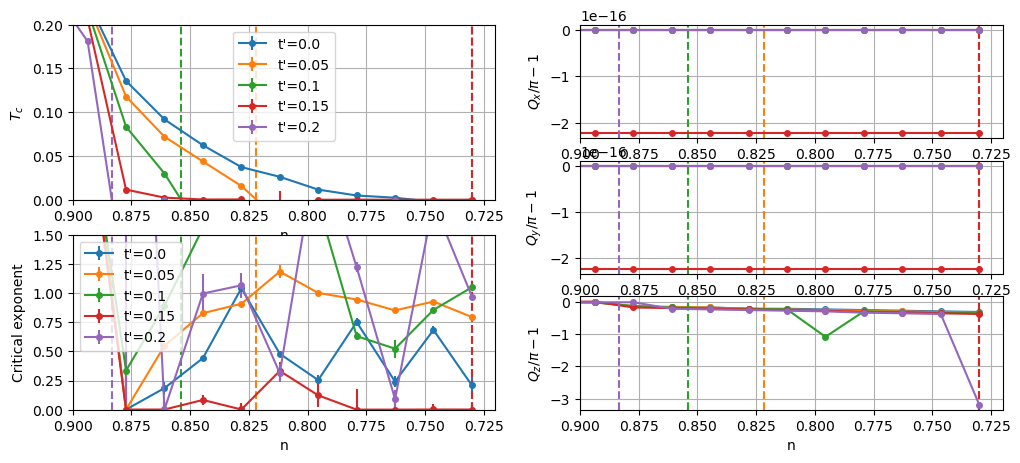

In [9]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., 0.05, 0.1, 0.15, 0.2]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qi = [[Q[i]-1 for Q in results['Qc']] for i in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for i, a in enumerate(ax[2:]):
        a.plot(n_list, Qi[i], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 15)

nk = 150
niw = 128
tp_list = [-0.05, -0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.005)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'method': 'matsubara_fft', 'niw': niw, 'niw_extr': True} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-08 12:04:58.688822
Starting serial run at: 2026-05-08 12:04:58.728301
Starting serial run at: 2026-05-08 12:04:58.731410
Starting serial run at: 2026-05-08 12:04:58.775898
Starting serial run at: 2026-05-08 12:04:58.795581
Starting serial run at: 2026-05-08 12:04:58.798235
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 11.6min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 11.7min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 34.7min
/home/ctort/miniconda3/envs/triqs/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Starting serial run at: 2026-05-08 12:39:39.593711


Starting serial run at: 2026-05-08 12:39:41.514927
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 34.7min remaining: 17.4min


Starting serial run at: 2026-05-08 12:39:42.051541


...

Starting serial run at: 2026-05-08 13:14:18.569095
[Parallel(n_jobs=6)]: Done  10 out of  19 | elapsed: 23.1min remaining: 20.8min


Starting serial run at: 2026-05-08 13:14:19.523697


Starting serial run at: 2026-05-08 13:14:19.929989
[Parallel(n_jobs=6)]: Done  12 out of  19 | elapsed: 23.1min remaining: 13.5min


Starting serial run at: 2026-05-08 13:14:20.234814


Starting serial run at: 2026-05-08 13:14:20.590914
[Parallel(n_jobs=6)]: Done  14 out of  19 | elapsed: 34.4min remaining: 12.3min
[Parallel(n_jobs=6)]: Done  16 out of  19 | elapsed: 34.4min remaining:  6.4min
[Parallel(n_jobs=6)]: Done  19 out of  19 | elapsed: 43.7min finished


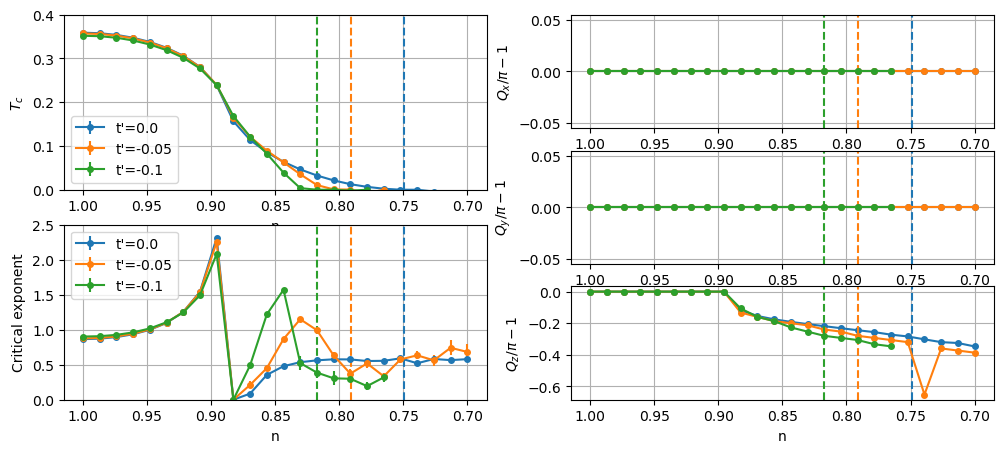

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., -0.05, -0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qi = [[Q[i]-1 for Q in results['Qc']] for i in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for i, a in enumerate(ax[2:]):
        a.plot(n_list, Qi[i], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.invert_xaxis()

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/negtp.png', dpi=100)
plt.show()

In [ ]:
save_dir = f'data/{dim}d/rpa_ba'

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 100
niw = 128
Gamma_list = [0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma, 'niw': niw, 'niw_extr': True, 'refine': False} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma,
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-05-15 05:15:51.299732
Starting serial run at: 2026-05-15 05:15:51.299745


Starting serial run at: 2026-05-15 05:15:51.322664
Starting serial run at: 2026-05-15 05:15:51.326467
Starting serial run at: 2026-05-15 05:15:51.376726
Starting serial run at: 2026-05-15 05:15:51.379596
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  5.0min remaining: 14.9min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.8min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 05:25:47.708346
Starting serial run at: 2026-05-15 05:25:47.708349
Starting serial run at: 2026-05-15 05:25:47.708813
Starting serial run at: 2026-05-15 05:25:47.711708
Starting serial run at: 2026-05-15 05:25:47.733452
Starting serial run at: 2026-05-15 05:25:47.733728
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  4.9min remaining: 14.8min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.7min remaining:  6.9min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 05:35:42.790420
Starting serial run at: 2026-05-15 05:35:42.809774
Starting serial run at: 2026-05-15 05:35:42.833245
Starting serial run at: 2026-05-15 05:35:42.836123
Starting serial run at: 2026-05-15 05:35:42.863344
Starting serial run at: 2026-05-15 05:35:42.868472
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.8min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  5.0min remaining: 14.9min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.7min remaining:  6.9min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 05:45:37.728594
Starting serial run at: 2026-05-15 05:45:37.728595
Starting serial run at: 2026-05-15 05:45:37.729138
Starting serial run at: 2026-05-15 05:45:37.729590
Starting serial run at: 2026-05-15 05:45:37.733205
Starting serial run at: 2026-05-15 05:45:37.733732
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  4.9min remaining: 14.8min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.8min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished


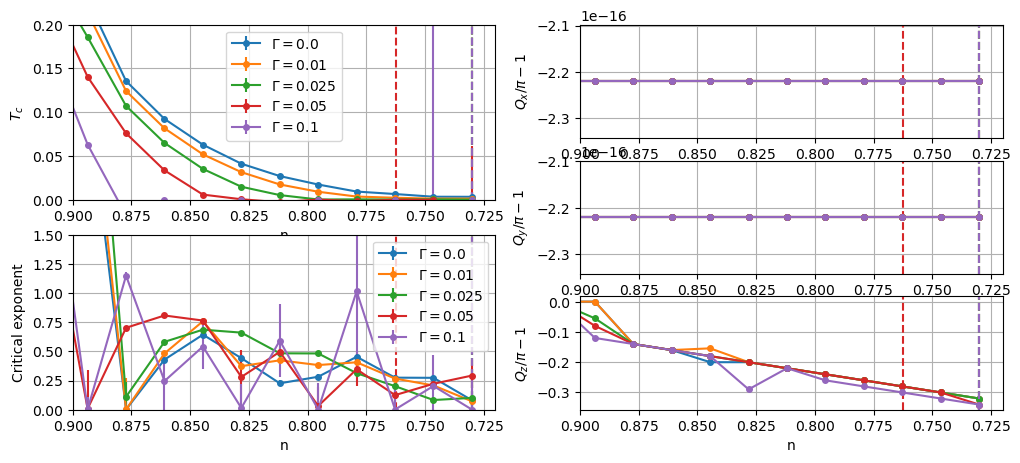

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

Gamma_list = [0., 0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qi = [[Q[i]-1 for Q in results['Qc']] for i in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    for i, a in enumerate(ax[2:]):
        a.plot(n_list, Qi[i], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()